## What is a Neural Network?

Neural networks are machine learning models inspired by the structure of the human brain:

- **Neuron**:  Basic computing unit that receives input and produces output
- **Layer**:  Collection of neurons, including input, hidden, and output layers
- **Weight**:  Connection strength that determines the importance of signals
- **Activation Function**:- **Activation Function**: Introduces nonlinearity, enabling the network to learn complex patterns

### Why Do We Need Neural Networks?

| Model | Decision Boundary | Use Cases |
|------|----------|----------|
| Logistic Regression | Linear | Simple classification |
| Neural Networks | Nonlinear, complex | Images, speech, text |

> **Neural networks are universal function approximators** — Theoretically can approximate any continuous function!

# Neural Network Fundamentals
## Neural Network Fundamentals

---

**Lecture 3 - Introduction to Neural Networks**

In this lecture, we will cover:
- Basic concepts of neural networks
- Building neural networks with PyTorch
- Hands-on: Handwritten digit recognition

## Why Choose PyTorch?

**PyTorch** is a deep learning framework developed by Facebook with the following advantages::

1. **Dynamic computation graph** — More flexible, easier to debug
2. **Pythonic** — Clean code, Pythonic style
3. **Powerful ecosystem** — torchvision, torchtext etc.
4. **Research-friendly** — Most AI papers are implemented in PyTorch
5. **Production deployment** — TorchScript, ONNX support

```python
# PyTorch Core Components
import torch                    # Tensor operations
import torch.nn as nn          # Neural network module
import torch.optim as optim    # Optimizer
from torch.utils.data import DataLoader  # Data loading
```

## Import required libraries

We will use the following libraries:
- `torch` — PyTorch core library
- `torchvision` — Computer vision tools
- `matplotlib` — Visualization
- `numpy` — Numerical computing
- `pandas` — Data processing

In [1]:
# Import required libraries
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:{device}')

Using device:cpu


## Loading the MNIST Dataset

### MNIST Dataset Introduction

MNIST is a classic handwritten digit dataset:

- **Number of images**:60,000 training images + 10,000 test images
- **Image dimensions**:28×28 pixels, grayscale
- **Labels**:0-9 10 digits (0-9)
- **Use case**:The "Hello World" of image classification"Hello World"

### Data Source

We use local CSV files (to avoid network issues):
- `mnist_train.csv` — Training data
- `mnist_test.csv` — Test data

In [2]:
# Load data from local CSV
print('Loading training data......')
train_df = pd.read_csv('mnist_train.csv', header=0)
test_df = pd.read_csv('mnist_test.csv', header=0)

print(f'Training data shape:{train_df.shape}')
print(f'Test data shape:{test_df.shape}')

Loading training data......
Training data shape:(6000, 785)
Test data shape:(1000, 785)


In [3]:
# Separate features and labels
# First column is labels, remaining 784 columns are pixel values
x_train = train_df.iloc[:, 1:].values.astype(np.float32)
y_train = train_df.iloc[:, 0].values.astype(np.int64)
x_test = test_df.iloc[:, 1:].values.astype(np.float32)
y_test = test_df.iloc[:, 0].values.astype(np.int64)

print(f'Training features shape:{x_train.shape}')  # (60000, 784)
print(f'Training labels shape:{y_train.shape}')  # (60000,)
print(f'Test features shape:{x_test.shape}')   # (10000, 784)
print(f'Test labels shape:{y_test.shape}')   # (10000,)

Training features shape:(6000, 784)
Training labels shape:(6000,)
Test features shape:(1000, 784)
Test labels shape:(1000,)


## Data Preprocessing

### Why Preprocess?

1. **Normalization** — Scale pixel values to [0, 1] range for faster convergence
2. **Reshape** — Reshape 784-D vectors to 28×28 images for visualization
3. **Convert to tensors** — PyTorch PyTorch requires Tensor format

### Normalization Formula

$$x_{normalized} = \frac{x}{255.0}$$

Scale pixel values from [0, 255] to [0, 1]

In [4]:
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to 28×28 images (for visualization)
x_train_img = x_train.reshape(-1, 28, 28)
x_test_img = x_test.reshape(-1, 28, 28)

# Convert to PyTorch tensors
x_train_tensor = torch.from_numpy(x_train)
y_train_tensor = torch.from_numpy(y_train)
x_test_tensor = torch.from_numpy(x_test)
y_test_tensor = torch.from_numpy(y_test)

print(f'Training tensor shape:{x_train_tensor.shape}')

Training tensor shape:torch.Size([6000, 784])


## Visualizing the Data

Let's look at some sample handwritten digits from the training data:

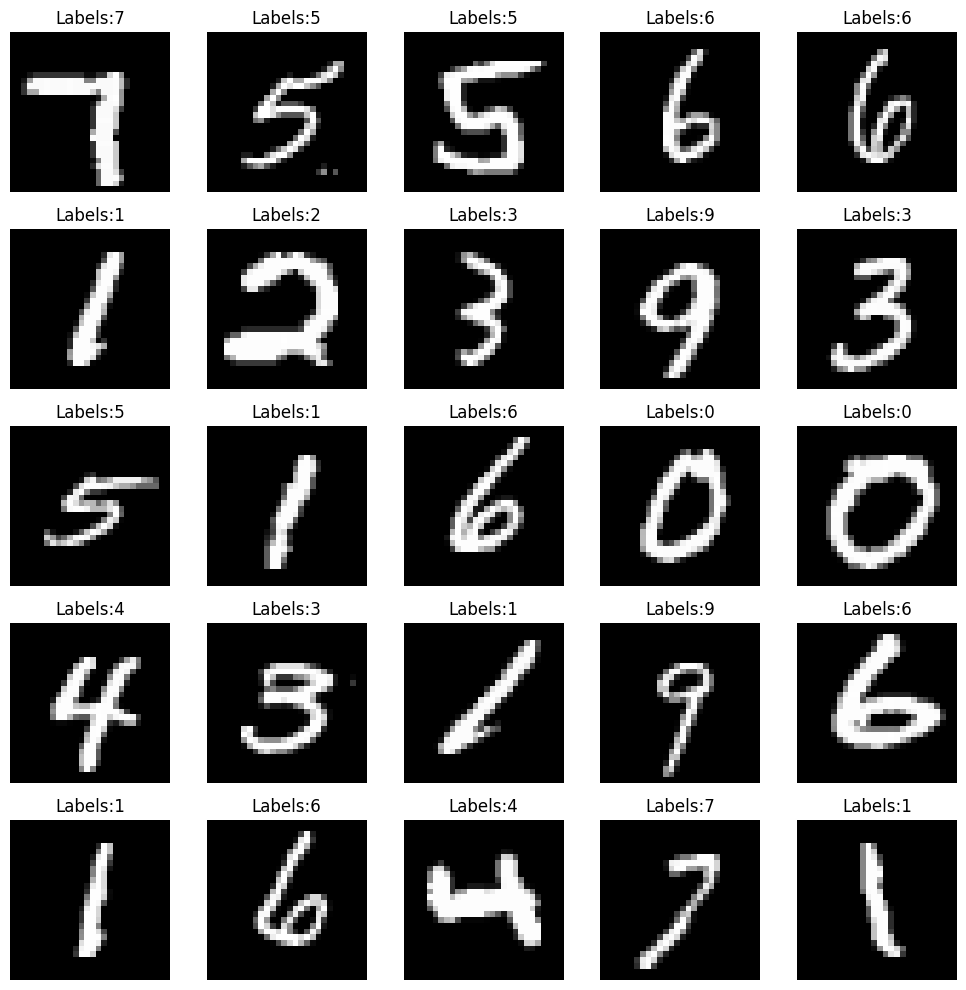

In [5]:
# Visualize 25 random samples
plt.figure(figsize=(10, 10))
for i in range(25):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train_img[idx], cmap='gray')
    plt.title(f'Labels:{y_train[idx]}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Label Distribution Statistics

Check if the dataset is balanced (similar count for each digit):

In [6]:
# Training set label distribution
unique, counts = np.unique(y_train, return_counts=True)
print('Training SetLabelsDistribution:')
for label, count in zip(unique, counts):
    print(f'  Digit {label}: {count} images ({count/len(y_train)*100:.1f}%)')

print(f'\nTotal: {len(y_train)} training images')

Training SetLabelsDistribution:
  Digit 0: 600 images (10.0%)
  Digit 1: 600 images (10.0%)
  Digit 2: 600 images (10.0%)
  Digit 3: 600 images (10.0%)
  Digit 4: 600 images (10.0%)
  Digit 5: 600 images (10.0%)
  Digit 6: 600 images (10.0%)
  Digit 7: 600 images (10.0%)
  Digit 8: 600 images (10.0%)
  Digit 9: 600 images (10.0%)

Total: 6000 training images


## Create DataLoader

### Why Do We Need DataLoader?

DataLoader DataLoader provides the following functionality::

1. **Batching(Batching)** — Process small batches at a time to save memory
2. **Shuffling(Shuffling)** — Shuffle each epoch to prevent overfitting
3. **Multi-process loading** — Accelerate data loading

### Key Parameters

- `batch_size` — Number of samples per batch (e.g., 64, 128)
- `shuffle` — Whether to shuffle data (True for training, False for testing)

In [7]:
# Create TensorDataset
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

# Create DataLoader
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # Shuffle data for training
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # Do not shuffle for testing
)

print(f'Number of training batches:{len(train_loader)}')  # 60000 / 64 = 937.5 ≈ 938
print(f'Number of test batches:{len(test_loader)}')   # 10000 / 64 = 156.25 ≈ 157

Number of training batches:94
Number of test batches:16


## Building the Neural Network Model

### Network Architecture Design

We will build a **Multi-Layer Perceptron (MLP)**:

```
Input Layer (784) → Hidden Layer 1 (256) → ReLU → Dropout → 
              Hidden Layer 2 (128) → ReLU → Dropout → 
              Output Layer (10) → Softmax
```

### Layer Functions

| Layer Type | Function |
|--------|------|
| **Dense (Linear)** | Fully connected layer, learns feature combinations |
| **ReLU** | Activation function, introduces nonlinearity |
| **Dropout** | Randomly drops neurons to prevent overfitting |
| **Softmax** | Outputs probability distribution (multi-class) |

In [8]:
# Define neural network model
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, num_classes=10, dropout_rate=0.3):
        super(MLP, self).__init__()
        
        # Layer 1: Input → Hidden Layer 1
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        
        # Layer 2: Hidden Layer 1 → Hidden Layer 2
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        
        # Output Layer: Hidden Layer 2 → Output
        self.fc3 = nn.Linear(hidden2, num_classes)
        # Note: Softmax is included in CrossEntropyLoss, no need to add separately
    
    def forward(self, x):
        # Forward propagation
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        return x

# Create model instance
model = MLP().to(device)
print('Model created successfully!!')

Model created successfully!!


## View Model Structure

Use `print()` to view model details:

In [9]:
print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [10]:
# Calculate model parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Total parameters:{total_params:,}')
print(f'Trainable parameters:{trainable_params:,}')

# Detailed calculation:
# Layer 1:784 × 256 + 256 = 200,960
# Layer 2:256 × 128 + 128 = 32,896
# Output Layer:128 × 10 + 10 = 1,290
# Total:235,146

Total parameters:235,146
Trainable parameters:235,146


## Defining Loss Function and Optimizer

### Loss Function: Cross Entropy Loss

**Cross Entropy Loss** is used for multi-class classification:

$$L = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

- $y_i$ — True labels (one-hot encoded)
- $\hat{y}_i$ — Predicted probability
- $C$ — Number of classes (10 digits)

> PyTorch's `nn.CrossEntropyLoss` already includes Softmax, so no need to add it to model output

### Optimizer: Adam

**Adam** is the most commonly used optimizer:
- Adaptive learning rate
- Fast convergence, good performance
- Requires almost no tuning

In [11]:
# Define loss function
criterion = nn.CrossEntropyLoss()

# Define optimizer
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f'Loss function:CrossEntropyLoss')
print(f'Optimizer: Adam (lr={learning_rate})')

Loss function:CrossEntropyLoss
Optimizer: Adam (lr=0.001)


## Train the model

### Training Process

Each epoch consists of the following steps::

1. **Forward propagation** — Input data, compute predictions
2. **Compute loss** — Compare predictions with true labels
3. **Backward pass** — Compute gradients
4. **Update parameters** — Optimizer updates weights

### Key Concepts

- **Epoch** — One pass through the entire training set
- **Batch** — Amount of data processed at once
- **Iteration** — Number of batches in one epoch

In [12]:
# Train the model
num_epochs = 20

# Record training history
train_losses = []
train_accs = []

print(f'Starting training for {num_epochs} epochs......\n')

for epoch in range(num_epochs):
    model.train()  # Set to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Iterate through each batch


Starting training for 20 epochs......



In [13]:
for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 1. Forward propagation
        outputs = model(inputs)
        
        # 2. Compute loss
        loss = criterion(outputs, targets)
        
        # 3. Backward pass
        optimizer.zero_grad()  # Clear gradients
        loss.backward()        # Compute gradients
        optimizer.step()       # Update parameters
        
        # Statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    # Calculate epoch average loss and accuracy


In [14]:
epoch_loss = running_loss / len(train_loader)
epoch_acc = 100.0 * correct / total

train_losses.append(epoch_loss)
train_accs.append(epoch_acc)

print(f'Epoch [{epoch+1}/{num_epochs}] | '
      f'Loss: {epoch_loss:.4f} | '
      f'Accuracy: {epoch_acc:.2f}%')

print('\nTraining complete!!')


Epoch [20/20] | Loss: 1.0640 | Accuracy: 67.57%

Training complete!!


## Visualizing the Training Process

Plot loss and accuracy curves to observe model convergence:

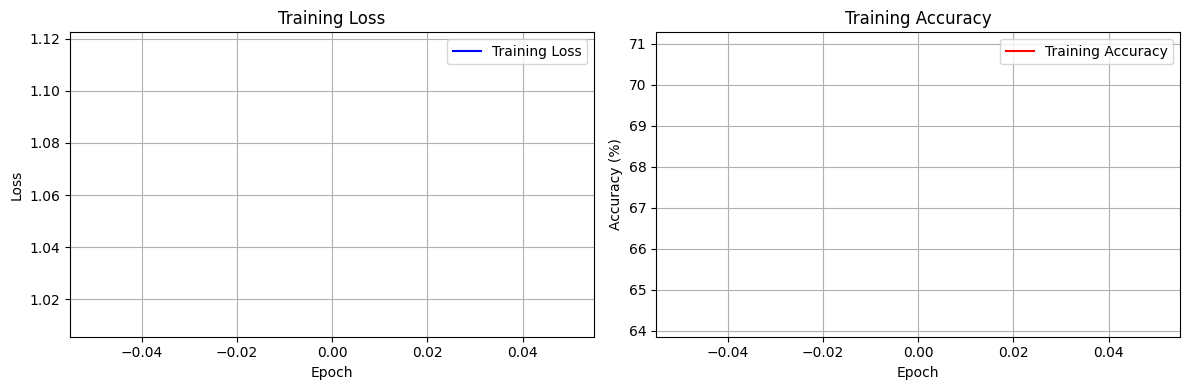

In [15]:
# Plot training curves
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(train_accs, 'r-', label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluating Model Performance

Evaluate model generalization on test set:

In [16]:
# Evaluate on test set
model.eval()  # Set to evaluation mode

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():  # No gradient computation
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item()
        
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

test_accuracy = 100.0 * correct / total
avg_test_loss = test_loss / len(test_loader)

print(f'Test set results:')
print(f'  Average loss:{avg_test_loss:.4f}')
print(f'  Accuracy:{test_accuracy:.2f}%')
print(f'  Correct predictions:{correct}/{total}')

Test set results:
  Average loss:0.5601
  Accuracy:84.20%
  Correct predictions:842/1000


## Confusion Matrix

Analyze model performance on each class:

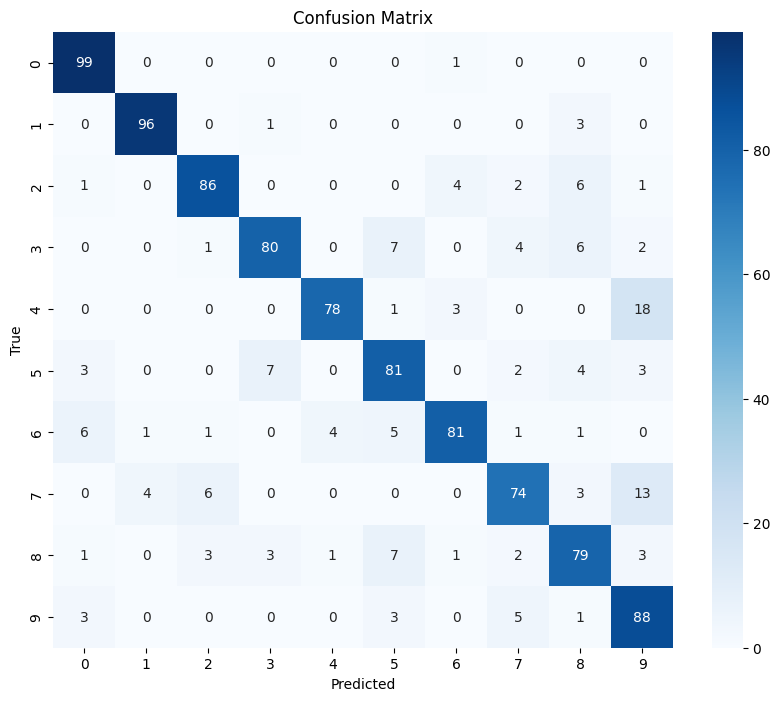


Classification Report:
              precision    recall  f1-score   support

           0     0.8761    0.9900    0.9296       100
           1     0.9505    0.9600    0.9552       100
           2     0.8866    0.8600    0.8731       100
           3     0.8791    0.8000    0.8377       100
           4     0.9398    0.7800    0.8525       100
           5     0.7788    0.8100    0.7941       100
           6     0.9000    0.8100    0.8526       100
           7     0.8222    0.7400    0.7789       100
           8     0.7670    0.7900    0.7783       100
           9     0.6875    0.8800    0.7719       100

    accuracy                         0.8420      1000
   macro avg     0.8488    0.8420    0.8424      1000
weighted avg     0.8488    0.8420    0.8424      1000



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Collect all predictions and true labels
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.numpy())

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, digits=4))

## Visualize predictions

Randomly select test samples and view model predictions:

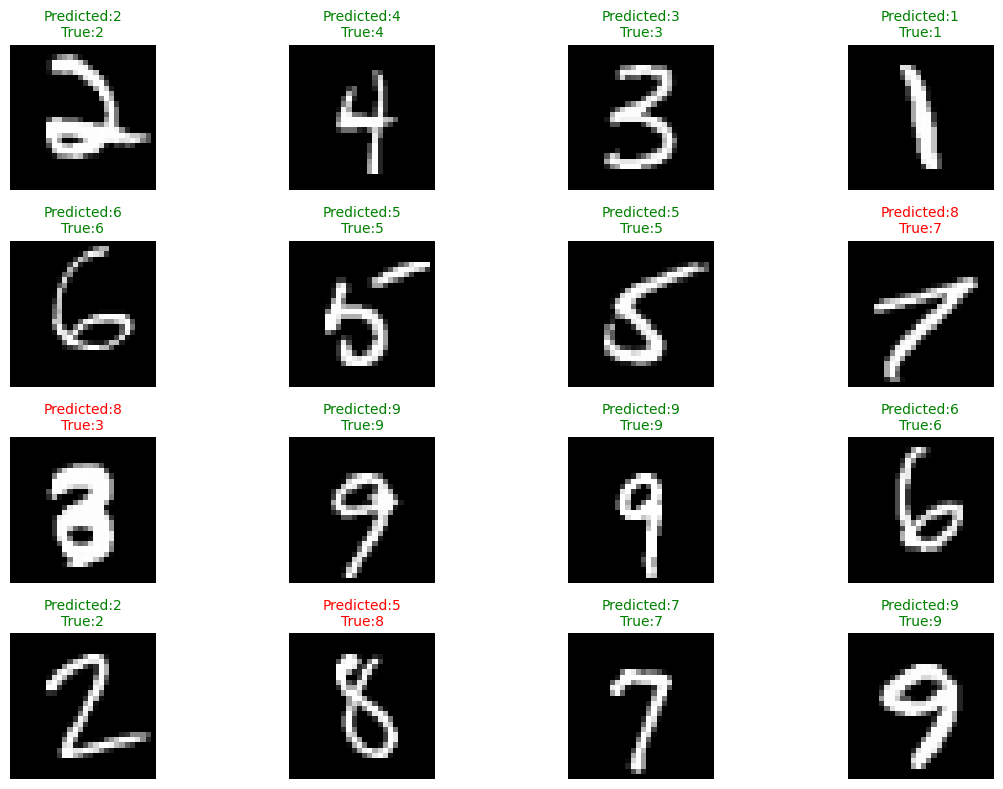

In [18]:
# Visualize predictions
model.eval()
with torch.no_grad():
    # Randomly select 16 test samples
    idx = np.random.randint(0, len(x_test), size=16)
    samples = torch.from_numpy(x_test[idx]).to(device)
    true_labels = y_test[idx]
    
    outputs = model(samples)
    _, preds = outputs.max(1)
    pred_labels = preds.cpu().numpy()
    
    # Plot
    plt.figure(figsize=(12, 8))
    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(x_test_img[idx[i]], cmap='gray')
        
        # Color: green=correct, red=incorrect
        color = 'green' if pred_labels[i] == true_labels[i] else 'red'
        plt.title(f'Predicted:{pred_labels[i]}\nTrue:{true_labels[i]}',
                 color=color, fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

## Summary

### Key Takeaways

1. **Neural Network Fundamentals**
   - Neural networks are universal function approximators
   - Can learn complex nonlinear relationships

2. **PyTorch Framework**
   - Dynamic computation graph, flexible and easy to use
   - Core components:Tensor, nn.Module, DataLoader

3. **Model Building Process**
   - Data loading and preprocessing
   - Define network architecture
   - Choose loss function and optimizer
   - Training and evaluation

4. **Key Concepts**
   - Batch, Epoch, Iteration
   - Dropout Dropout prevents overfitting
   - ReLU ReLU activation function

## Next Steps

### Advanced Topics

1. **Convolutional Neural Networks (CNN)**
   - More suitable for image processing
   - Uses convolutional and pooling layers

2. **Hyperparameter Tuning**
   - Learning rate scheduling
   - Network depth and width
   - Dropout Dropout ratio

3. **Regularization Techniques**
   - L2 L2 regularization
   - Batch Normalization
   - Data Augmentation

4. **Pre-trained Models**
   - Transfer Learning
   - Fine-tuning

## References

### PyTorch Official Resources
- [PyTorch Tutorials](https://pytorch.org/tutorials/)
- [PyTorch Documentation](https://pytorch.org/docs/)

### Deep Learning Courses
- [Deep Learning Specialization (Coursera)](https://www.coursera.org/specializations/deep-learning)
- [Fast.ai](https://www.fast.ai/)

### Books
- 《Deep Learning》by Ian Goodfellow
- 《Deep Learning with PyTorch》

---

**Thanks for learning! Feel free to ask any questions。** 🎓